## 로컬 환경 설정

로컬 Jupyter나 VS Code에서 실행할 때 현재 경로의 부모를 탐색해 저장소 루트를 찾는다. 로컬 dependency는 notebook 설치 셀보다 `uv sync`로 맞춘 환경을 우선한다.


In [1]:
import os
import sys
from pathlib import Path

# torch import 전에 반드시 설정
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_IB_DISABLE"] = "1"

# 절대 경로로 직접 지정
LOCAL_PROJECT_PATH = Path("/home/undergraduate/20231372_TY/Pytorch/VLM")
os.chdir(LOCAL_PROJECT_PATH)

if str(LOCAL_PROJECT_PATH) not in sys.path:
    sys.path.insert(0, str(LOCAL_PROJECT_PATH))

print("Project root:", os.getcwd())
# 출력: /home/undergraduate/20231372_TY/Pytorch/VLM  이 나와야 정상

Project root: /home/undergraduate/20231372_TY/Pytorch/VLM


## 공통 import

노트북 전체에서 사용하는 외부 패키지와 저장소 공용 모듈을 한 번만 불러온다.


In [2]:
import os
import json
from dataclasses import dataclass
from pathlib import Path

MPLCONFIGDIR = Path(os.environ.get("MPLCONFIGDIR", "/tmp/matplotlib"))
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import torch
import transformers
from PIL import Image
from torch.utils.data import Dataset

from utils.caption_metrics import compute_caption_metrics

from utils.device_utils import (
    get_device_info,
    release_cuda_memory,
    resolve_device,
)

from utils.logger_utils import configure_logger, get_logger

from utils.smolvlm_utils import (
    align_model_generation_config_with_tokenizer,
    generate_caption_splits,
    load_model_and_processor,
    resolve_auto_model_class,
    resolve_torch_dtype,
)

from utils.training_utils import (
    build_config_payload,
    save_json,
)

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from utils.caption_metrics import safe_compute_single_caption_scores
from utils.lora_finetuning import train_and_evaluate_lora_rank

/home/undergraduate/20231372_TY/envs/smolvlm_lora/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 실행 설정과 상수

모델, prompt, output 경로, LoRA target module, Trainer hyperparameter를 고정한다. 기본 실행은 rank 4/8/16 sweep으로 LoRA adapter 크기에 따른 비용과 성능 변화를 비교한다.


In [3]:
# 실행 설정과 상수
# COCO가 아니라 NurViD에서 추출한 의료 이미지 + 직접 작성한 GT caption을 사용한다.

LOGGER = get_logger("nurvid_smolvlm_lora")

@dataclass(slots=True)
class LoRAFinetuneConfig:
    model_name: str = "HuggingFaceTB/SmolVLM-256M-Instruct"
    prompt: str = "Describe this medical scene in one concise English sentence."

    # rank 3개로 비교
    ranks: tuple[int, ...] = (4, 8)

    target_modules: tuple[str, ...] = (
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    )

    seed: int = 42
    device: str = "cuda"

    per_device_train_batch_size: int = 1
    per_device_eval_batch_size: int = 1
    gradient_accumulation_steps: int = 4  # 1 → 4 (effective batch=4)

    # 데이터 30개니까 epoch 늘림
    num_train_epochs: int = 10            # 1 → 10
    learning_rate: float = 2e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1            # 0.03 → 0.1
    logging_steps: int = 1
    max_new_tokens: int = 64             # 24 → 64

    image_dir: Path = Path("dataset/selected_images")
    caption_path: Path = Path("dataset/nurvid_captions.jsonl")

    data_dir: Path = Path("data/nurvid-lora-finetuning")
    output_dir: Path = Path("model/nurvid-lora-finetuning")

In [4]:
config_lora_ft = LoRAFinetuneConfig()

config_lora_ft.data_dir.mkdir(parents=True, exist_ok=True)
config_lora_ft.output_dir.mkdir(parents=True, exist_ok=True)

print("Image dir:", config_lora_ft.image_dir)
print("Caption path:", config_lora_ft.caption_path)
print("Output dir:", config_lora_ft.output_dir)

Image dir: dataset/selected_images
Caption path: dataset/nurvid_captions.jsonl
Output dir: model/nurvid-lora-finetuning


## LoRA 학습 준비

LoRA fine-tuning 설정, device 정보, 저장 경로를 준비한다. = 학습을 시작하기 전 환경을 준비하고 설정을 기록하는 코드


In [5]:
# LoRA 학습 준비

configure_logger()
config_lora_ft = LoRAFinetuneConfig()

# 디렉토리 생성
config_lora_ft.data_dir.mkdir(parents=True, exist_ok=True)
config_lora_ft.output_dir.mkdir(parents=True, exist_ok=True)

# 이미지 / 캡션 파일 확인
image_files = sorted([
    p for p in config_lora_ft.image_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

if not config_lora_ft.image_dir.exists():
    raise FileNotFoundError(f"이미지 폴더가 없습니다: {config_lora_ft.image_dir}")

if not config_lora_ft.caption_path.exists():
    raise FileNotFoundError(f"캡션 파일이 없습니다: {config_lora_ft.caption_path}")

LOGGER.info(
    "Starting NurViD LoRA run | model=%s images=%s ranks=%s output_dir=%s",
    config_lora_ft.model_name,
    len(image_files),
    config_lora_ft.ranks,
    config_lora_ft.output_dir,
)

# GPU 확인
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU가 필요합니다. 현재 torch.cuda.is_available() = False 입니다.")

device = resolve_device(config_lora_ft.device)

device_info = get_device_info(str(device))
save_json(
    config_lora_ft.output_dir / "device_info.json",
    {
        **device_info,
        "device": str(device_info["device"]),
    },
)

print("Device:", device)
print("Image count:", len(image_files))
print("Caption file:", config_lora_ft.caption_path)

15:09:41 |   22 | INFO     | Starting NurViD LoRA run | model=HuggingFaceTB/SmolVLM-256M-Instruct images=35 ranks=(4, 8) output_dir=model/nurvid-lora-finetuning
Device: cuda
Image count: 35
Caption file: dataset/nurvid_captions.jsonl


In [6]:
# selected_images 안의 이미지 목록으로 caption 템플릿 만들기
# ✅ 파일이 이미 존재하면 실행하지 않음

caption_path = Path("dataset/nurvid_captions.jsonl")
image_dir = Path("dataset/selected_images")

if caption_path.exists():
    print(f"[SKIP] 캡션 파일이 이미 존재합니다: {caption_path}")
    print("[INFO] 기존 캡션 파일을 유지합니다.")
else:
    image_files = sorted([
        p.name for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    with open(caption_path, "w", encoding="utf-8") as f:
        for image_name in image_files:
            row = {
                "image": image_name,
                "caption": "A nurse performing a medical action in a hospital setting."
            }
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    print(f"[OK] Caption template saved: {caption_path}")

[SKIP] 캡션 파일이 이미 존재합니다: dataset/nurvid_captions.jsonl
[INFO] 기존 캡션 파일을 유지합니다.


In [7]:
# NurViD 데이터 split 준비

def load_nurvid_caption_rows(caption_path: Path, image_dir: Path):
    rows = []

    with open(caption_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            item = json.loads(line)
            image_path = image_dir / item["image"]

            if not image_path.exists():
                print(f"[WARN] 이미지 파일 없음: {image_path}")
                continue

            rows.append({
                "image": Image.open(image_path).convert("RGB"),
                "caption": item["caption"],
                "image_path": str(image_path),
                "image_name": item["image"],
            })

    return rows


all_rows = load_nurvid_caption_rows(
    caption_path=config_lora_ft.caption_path,
    image_dir=config_lora_ft.image_dir,
)

print("전체 NurViD 이미지 개수:", len(all_rows))

if len(all_rows) == 0:
    raise ValueError("사용할 이미지가 없습니다. selected_images와 nurvid_captions.jsonl을 확인하세요.")

# 데이터가 적으므로 80:20으로 간단 split
split_idx = max(1, int(len(all_rows) * 0.8))

train_rows = all_rows[:split_idx]
val_rows = all_rows[split_idx:]

# 이미지 수가 너무 적어서 validation이 비면 train 일부를 val로 재사용
if len(val_rows) == 0:
    val_rows = train_rows[:1]

# Before/After 비교용 샘플
comparison_samples = all_rows[: min(4, len(all_rows))]

# metric 계산용 샘플
metric_samples = all_rows

manifest = {
    "train": [row["image_name"] for row in train_rows],
    "val": [row["image_name"] for row in val_rows],
    "metric": [row["image_name"] for row in metric_samples],
    "comparison": [row["image_name"] for row in comparison_samples],
}

save_json(
    config_lora_ft.data_dir / "split_manifest.json",
    manifest,
)

print("train rows:", len(train_rows))
print("val rows:", len(val_rows))
print("metric samples:", len(metric_samples))
print("comparison samples:", len(comparison_samples))

전체 NurViD 이미지 개수: 35
train rows: 28
val rows: 7
metric samples: 35
comparison samples: 4


In [8]:
# zero-shot 추론 준비(LoRA 학습 전 기준점을 만들기 위해 모델을 로드하는 코드)

# zero-shot baseline 생성을 위해 base SmolVLM과 processor를 먼저 로드합니다.
# auto_model_class와 torch_dtype는 이후 rank별 LoRA 학습 helper가 같은 model class와 dtype 정책을 재사용하도록 보관합니다.

# 이 gpu에서 모델을 어떤 정밀도로 올릴지 자동으로 결정
# auto로 두면 T4에 맞게 자동으로 FP16을 선택
torch_dtype = resolve_torch_dtype(device=device, torch_dtype=torch.float16)

# SmolVLM 같은 멀티모달 모델을 로드할 때 어떤 클래스를 써야 하는지 자동으로 찾아주는 코드
# SmolVLM은 이미지 + 텍스트를 처리하는 멀티모달이므로 AutoModelForImageTextToText
# 이 값을 저장해두는 이유는 나중에 rank별 LoRA 학습할 때도 같은 클래스를 재사용하기 위함
auto_model_class = resolve_auto_model_class(transformers)

# SmolVLM 모델과 프로세서를 한 번에 로드하는 함수
zero_shot_bundle = load_model_and_processor(
    model_id=config_lora_ft.model_name, # 어떤 모델을 불러올지 지정(SmolVLM-256M-Instruct)
    device=device, # 모델을 어디에 올릴지 지정
    torch_dtype=torch_dtype, # FP16
    prefer_flash_attention=False, # FlashAttention은 Attention 연산을 더 빠르게 하는 기술인데, T4에서는 지원되지 않아 끄는 것
)
'''
반환값 : 모델과 프로세서를 딕셔너리로 묶어서 반환해준다.
  zero_shot_bundle = {
      "model":     실제 신경망,이미지를 보고 캡션을 생성
      "processor": 이미지/텍스트를 모델 입력 형식으로 변환
  }
'''

# 반환값에서 각각 꺼낸다
processor = zero_shot_bundle["processor"]
zero_shot_model = zero_shot_bundle["model"]

# 모델의 생성 설정과 토크나이저를 서로 일치시키는 코드
# 모델과 토크나이저의 문장 끝 토큰을 일치시킨다.

'''
맞추기 전                    맞춘 후
─────────────   ──────────────
모델:  eos = 2               모델:  eos = 32000
토크나이저: eos = 32000  →   토크나이저: eos = 32000
→ 캡션이 안 끝남              → 캡션이 정상 종료
'''

align_model_generation_config_with_tokenizer(zero_shot_model, processor.tokenizer)

print("model loaded:", type(zero_shot_model))
print("processor loaded:", type(processor))
print("torch dtype:", torch_dtype)
print("device:", device)


model loaded: <class 'transformers.models.idefics3.modeling_idefics3.Idefics3ForConditionalGeneration'>
processor loaded: <class 'transformers.models.idefics3.processing_idefics3.Idefics3Processor'>
torch dtype: torch.float16
device: cuda


## zero-shot 추론 실행과 평가

LoRA 학습 전 기준 caption과 metric을 만든다. = 아래의 코드는 아무것도 학습하지 않은 상태에서 모델이 캡션을 얼마나 잘 생성하는지 측정하는 코드

> 점수 계산 zero_shot_scores

```
모델 생성: "A dog is running in a field"
정답:      "A brown dog runs on the grass"
        ↓
BLEU   = 0.32
ROUGE  = 0.45
METEOR = 0.38
CIDEr  = 0.71
```

safe가 붙은 이유는 점수 계산 중 오류가 나도 프로그램이 멈추지 않게 처리했기 때문이다



In [9]:
# zero-shot 추론 실행과 평가

zero_shot_outputs = generate_caption_splits(
    label="Zero-shot",
    model=zero_shot_model,
    processor=processor,
    sample_splits={
        "comparison": comparison_samples,
        "metric": metric_samples,
    },
    device=device,
    prompt=config_lora_ft.prompt,
    max_new_tokens=config_lora_ft.max_new_tokens,
    batch_size=config_lora_ft.per_device_eval_batch_size,
    logger=LOGGER,
)

zero_shot_comparison_predictions = zero_shot_outputs["comparison"]
zero_shot_metric_predictions = zero_shot_outputs["metric"]

# metric_samples에서 GT caption만 꺼내기
references = [sample["caption"] for sample in metric_samples]

# 점수 계산
zero_shot_scores = compute_caption_metrics(
    predictions=zero_shot_metric_predictions,
    references=references,
)

# 점수 저장
save_json(
    config_lora_ft.output_dir / "zero_shot_caption_scores.json",
    zero_shot_scores,
)

print("Zero-shot scores:", zero_shot_scores)

# 생성 결과도 확인용으로 저장
zero_shot_result_rows = []

for sample, pred in zip(metric_samples, zero_shot_metric_predictions):
    zero_shot_result_rows.append({
        "image_name": sample["image_name"],
        "gt_caption": sample["caption"],
        "zero_shot_prediction": pred,
    })

save_json(
    config_lora_ft.output_dir / "zero_shot_predictions.json",
    zero_shot_result_rows,
)

print("Zero-shot predictions saved.")

15:09:46 |  366 | INFO     | Running zero-shot caption generation for comparison samples


Zero-shot comparison captions: 100%|██████████| 4/4 [00:05<00:00,  1.28s/it]

15:09:52 |  366 | INFO     | Running zero-shot caption generation for metric samples



Zero-shot metric captions: 100%|██████████| 35/35 [00:44<00:00,  1.26s/it]


Zero-shot scores: {'bleu': 0.0, 'meteor': 0.1032071688734147, 'cider_d': 0.023962586154704844}
Zero-shot predictions saved.


## zero-shot model 메모리 정리

baseline caption을 만든 뒤 base model 메모리를 비워 rank별 LoRA 학습 공간을 확보한다.

 = 더 이상 필요없는 zero-shot 모델을 GPU 메모리에서 제거하는 코드이다. (그냥 두면 GPU 메모리를 계속 차지하기 때문)


In [10]:
try:
    del zero_shot_model
except:
    pass

try:
    del zero_shot_bundle
except:
    pass

import gc
gc.collect()

torch.cuda.empty_cache()

print("memory cleanup done")

memory cleanup done


## LoRA 학습 실행

설정된 rank 목록을 순회하며 LoRA 학습, 평가, artifact 저장을 실행한다. 기본값은 rank 4/8/16 sweep이다.


In [11]:
# LoRA 학습 실행

rank_summary_rows = []
rank_results = []
full_finetuning_trainable_params = None

# zero-shot 모델 메모리 해제: 이미 삭제되어 있어도 에러 안 나게 처리
try:
    del zero_shot_model
except NameError:
    pass

try:
    del zero_shot_bundle["model"]
except Exception:
    pass

torch.cuda.empty_cache()
release_cuda_memory(device, torch)

for rank in config_lora_ft.ranks:
    rank_result = train_and_evaluate_lora_rank(
        rank=int(rank),
        config=config_lora_ft,
        processor=processor,
        auto_model_class=auto_model_class,
        transformers_module=transformers,
        torch_module=torch,
        torch_dtype=torch.float16,   # TITAN Xp에서는 bfloat16보다 float16 권장
        device=device,
        train_rows=train_rows,
        val_rows=val_rows,
        comparison_samples=comparison_samples,
        metric_samples=metric_samples,
        zero_shot_comparison_predictions=zero_shot_comparison_predictions,
        zero_shot_metric_predictions=zero_shot_metric_predictions,
        full_finetuning_trainable_params=full_finetuning_trainable_params,
        logger=LOGGER,
    )

    full_finetuning_trainable_params = rank_result["full_finetuning_trainable_params"]
    rank_summary_rows.append(rank_result["summary"])
    rank_results.append(rank_result)

15:10:44 |   75 | INFO     | Starting LoRA fine-tuning | rank=4 train_rows=28 val_rows=7 effective_batch=4 estimated_optimizer_steps=70


Epoch,Training Loss,Validation Loss
1,4.187900,4.134798
2,2.688100,3.006933
3,2.426600,2.323460
4,1.962100,2.017922
5,1.483800,1.823628
6,1.063200,1.696983
7,1.368500,1.630615
8,0.634000,1.594053
9,1.150500,1.574652
10,0.590100,1.567005


16:05:00 |   86 | INFO     | Training complete, starting evaluation | rank=4


16:05:21 |   94 | INFO     | LoRA trainable parameters | trainable_params=1442304 all_params=257927232 trainable_ratio=0.5592%
16:05:21 |  366 | INFO     | Running lora rank 4 caption generation for comparison samples


LoRA rank 4 comparison captions: 100%|██████████| 4/4 [00:13<00:00,  3.35s/it]

...

17:02:10 |   94 | INFO     | LoRA trainable parameters | trainable_params=2884608 all_params=259369536 trainable_ratio=1.1122%
17:02:10 |  366 | INFO     | Running lora rank 8 caption generation for comparison samples


LoRA rank 8 comparison captions: 100%|██████████| 4/4 [00:12<00:00,  3.19s/it]

17:02:22 |  366 | INFO     | Running lora rank 8 caption generation for metric samples



LoRA rank 8 metric captions: 100%|██████████| 35/35 [01:54<00:00,  3.26s/it]


17:04:23 |   42 | INFO     | Terminal before/after comparison
17:04:23 |   45 | INFO     | Metrics | bleu=0.0000->0.6130 (delta=0.6130) meteor=0.1032->0.7452 (delta=0.6420) cider_d=0.0240->4.9091 (delta=4.8851)
17:04:23 |   60 | INFO     | Sample 1 | filename=n/a
17:04:23 |   61 | INFO     | GT: A nurse administering a subcutaneous injection into the abdominal area of a patient in a clinical setting
17:04:23 |   62 | INFO     | Zero-shot: Two women in blue uniforms are preparing to give birth.
17:04:23 |   63 | INFO     | Fine-tuned: A nurse administering an intramuscular injection into the abdominal area of a patient in a clinical setting
17:04:23 |   60 | INFO     | Sample 2 | filename=n/a
17:04:23 |   61 | INFO     | GT: A nurse preparing a syringe for a subcutaneous injection in a clinical setting
17:04:23 |   62 | INFO     | Zero-shot: Two women in blue uniforms are giving a medical test to a patient.
17:04:23 |   63 | INFO     | Fine-tuned: A nurse preparing a syringe for a subcu

## rank summary와 method comparison 저장

LoRA rank별 결과와 `Zero-shot / Full FT / LoRA` 비교 table을 함께 저장한다.

- full fine-tuning 산출물이 없으면 skip reason을 남기고 LoRA 결과는 그대로 저장한다.





> rank summary와 method comparizon 저장 코드

이 코드는 모든 학습 결과를 한 곳에 모아서 정리하고 저장하는 코드이다.

> rank_summary, method_comparison

```
rank_summary.json      → 모든 정보 (종합)
method_comparison.json → 비교 결과만 (간단)
```







In [12]:
# rank summary와 zero-shot / LoRA 비교 결과 저장
# Full Fine-tuning 결과는 사용하지 않고, Zero-shot과 LoRA 결과만 비교한다.

config_payload = build_config_payload(config_lora_ft)

# rank_results 안에는 rank별 before_after_report, caption_scores 등이 들어있음
method_comparison_report = {
    "zero_shot_caption_scores": zero_shot_scores,
    "lora_results": rank_results,
}

# 전체 요약 저장
save_json(
    config_lora_ft.output_dir / "rank_summary.json",
    {
        "config": config_payload,
        "zero_shot_caption_scores": zero_shot_scores,
        "rows": rank_summary_rows,
        "method_comparison_report": method_comparison_report,
    },
)

# 비교 결과만 따로 저장
save_json(
    config_lora_ft.output_dir / "method_comparison.json",
    method_comparison_report,
)

# 결과 출력
print("Rank summary rows:")
for row in rank_summary_rows:
    print(row)

result_lora_ft = {
    "config": config_payload,
    "zero_shot_caption_scores": zero_shot_scores,
    "rows": rank_summary_rows,
    "method_comparison_report": method_comparison_report,
}

print("Saved:")
print(config_lora_ft.output_dir / "rank_summary.json")
print(config_lora_ft.output_dir / "method_comparison.json")

Rank summary rows:
{'rank': 4, 'lora_alpha': 8, 'trainable_params': 1442304, 'total_params': 257927232, 'full_finetuning_trainable_params': 256484928, 'trainable_ratio': 0.005591902758061622, 'vs_full_finetuning_ratio': 0.005623347973101951, 'vs_full_finetuning_reduction_factor': 177.83000532481364, 'vs_full_finetuning_saved_params': 255042624, 'vs_full_finetuning_saved_ratio': 0.9943766520268981, 'eval_loss': 1.5670052766799927, 'caption_scores': {'available': True, 'zero_shot': {'bleu': 0.0, 'meteor': 0.1032071688734147, 'cider_d': 0.023962586154704844}, 'fine_tuned': {'bleu': 0.32236398288320733, 'meteor': 0.5605098966737433, 'cider_d': 1.2163877988741267}, 'delta': {'bleu': 0.322364, 'meteor': 0.457303, 'cider_d': 1.192425}}}
{'rank': 8, 'lora_alpha': 16, 'trainable_params': 2884608, 'total_params': 259369536, 'full_finetuning_trainable_params': 256484928, 'trainable_ratio': 0.011121614529163517, 'vs_full_finetuning_ratio': 0.011246695946203903, 'vs_full_finetuning_reduction_factor

## LoRA fine-tuning 결과 시각화

`show_lora_rank_summary`로 zero-shot, full fine-tuning, rank별 LoRA 결과를 같은 metric 축에서 비교한다. full fine-tuning 산출물이 없거나 metric을 읽지 못한 경우에는 해당 항목을 표시하지 않는다.

* 아래 코드는 zero-shot, Full FT, LoRA Rank별 결과를 그래프로 그리는 코드이다.



> zero-shot 점수 꺼낼때


```
계산 성공 → zero_shot_plot_metrics = {"bleu": 0.21, ...}  ← 그래프에 표시
계산 실패 → zero_shot_plot_metrics = None                 ← 그래프에서 제외
```




17:04:24 |  224 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
17:04:24 |  224 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
17:04:24 |  224 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
17:04:24 |  224 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


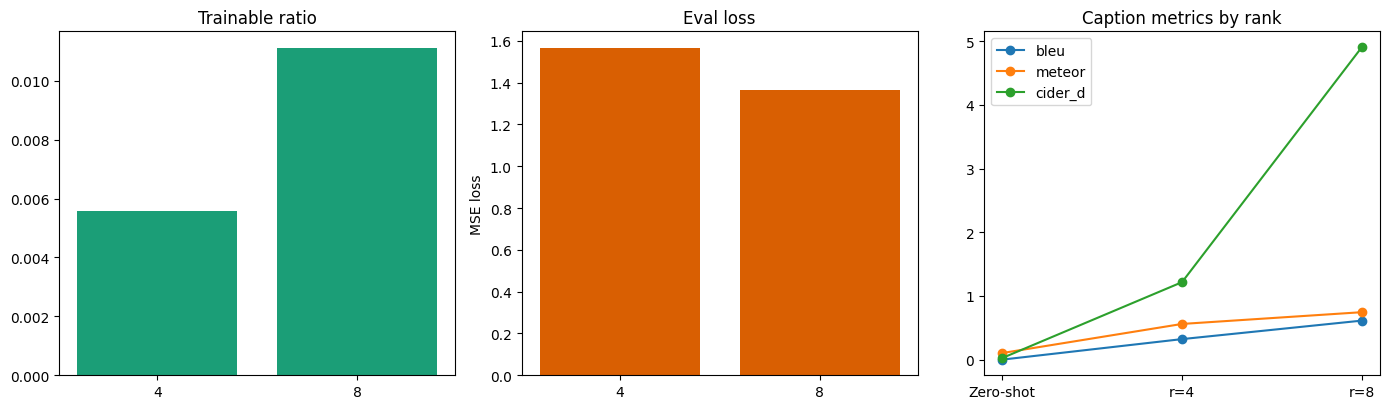

(<Figure size 1400x420 with 3 Axes>,
 [<Axes: title={'center': 'Trainable ratio'}>,
  <Axes: title={'center': 'Eval loss'}, ylabel='MSE loss'>,
  <Axes: title={'center': 'Caption metrics by rank'}>])

In [13]:
import json
from pathlib import Path
from utils.visualization import show_lora_rank_summary

output_dir = Path("model/nurvid-lora-finetuning")

with open(output_dir / "rank_summary.json") as f:
    rank_summary = json.load(f)

with open(output_dir / "zero_shot_caption_scores.json") as f:
    zero_shot_scores = json.load(f)

show_lora_rank_summary(
    rank_summary["rows"],
    zero_shot_metrics=zero_shot_scores,
    full_finetuning_metrics=None,
)

In [14]:
"""
NurViD LoRA Fine-tuning 결과 시각화 스크립트
학습 끝난 후 실행: python visualize_results.py
"""

import json
import os
from pathlib import Path
from collections import Counter

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── 경로 설정 ─────────────────────────────────────────────────────────────────
CAPTION_PATH   = Path("dataset/nurvid_captions.jsonl")
OUTPUT_DIR     = Path("model/nurvid-lora-finetuning")
RANK           = 4
RANK_DIR       = OUTPUT_DIR / f"rank-{RANK}"
SAVE_PATH      = OUTPUT_DIR / "visualization_summary.png"

# ── 색상 팔레트 ───────────────────────────────────────────────────────────────
BG      = "#0f1117"
PANEL   = "#1a1d27"
ACCENT1 = "#4f8ef7"   # 파랑  (Zero-shot)
ACCENT2 = "#34d399"   # 초록  (LoRA)
ACCENT3 = "#f472b6"   # 핑크  (GT)
TEXT    = "#e2e8f0"
SUBTEXT = "#94a3b8"

CAT_COLORS = {
    "subcutaneous_injection": "#4f8ef7",
    "intramuscular_injection": "#f472b6",
    "electrocardiogram":       "#fbbf24",
    "oxygen_therapy":          "#34d399",
}

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    "#2d3148",
    "axes.labelcolor":   TEXT,
    "xtick.color":       SUBTEXT,
    "ytick.color":       SUBTEXT,
    "text.color":        TEXT,
    "grid.color":        "#2d3148",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
})

# ── 데이터 로드 헬퍼 ──────────────────────────────────────────────────────────
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_load_json(path):
    try:
        return load_json(path)
    except Exception:
        return None

# ── 카테고리 추출 ─────────────────────────────────────────────────────────────
def get_category(image_name: str) -> str:
    for cat in CAT_COLORS:
        if image_name.startswith(cat):
            return cat
    return "other"

# ══════════════════════════════════════════════════════════════════════════════
#  Figure 구성
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle(
    "NurViD LoRA Fine-tuning  ·  SmolVLM-256M",
    fontsize=20, fontweight="bold", color=TEXT, y=0.97
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45, wspace=0.35,
    left=0.06, right=0.97, top=0.91, bottom=0.07
)

ax_pie   = fig.add_subplot(gs[0, 0])   # 데이터 분포 파이차트
ax_bar   = fig.add_subplot(gs[0, 1])   # 카테고리별 이미지 수
ax_score = fig.add_subplot(gs[0, 2])   # Before/After 점수 비교
ax_loss  = fig.add_subplot(gs[1, 0])   # Train/Val Loss 곡선
ax_ba    = fig.add_subplot(gs[1, 1:])  # Before/After 캡션 텍스트

# ─── 1. 데이터 분포 파이차트 ──────────────────────────────────────────────────
captions = load_jsonl(CAPTION_PATH)
cat_counts = Counter(get_category(r["image"]) for r in captions)

labels  = list(cat_counts.keys())
sizes   = list(cat_counts.values())
colors  = [CAT_COLORS.get(l, "#888") for l in labels]
short   = {
    "subcutaneous_injection":  "Subcut.",
    "intramuscular_injection": "IM",
    "electrocardiogram":       "ECG",
    "oxygen_therapy":          "O₂ Therapy",
}

wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=[short.get(l, l) for l in labels],
    colors=colors,
    autopct="%1.0f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    textprops=dict(color=TEXT, fontsize=9),
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color(BG)
    at.set_fontweight("bold")
ax_pie.set_title("Dataset Distribution\n(total: %d images)" % len(captions),
                 fontsize=11, color=TEXT, pad=10)

# ─── 2. 카테고리별 이미지 수 막대그래프 ──────────────────────────────────────
x_pos = np.arange(len(labels))
bars  = ax_bar.bar(x_pos, sizes, color=colors, width=0.55,
                   edgecolor=BG, linewidth=1.5)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels([short.get(l, l) for l in labels], fontsize=9)
ax_bar.set_ylabel("# Images", fontsize=10)
ax_bar.set_title("Images per Category", fontsize=11, color=TEXT, pad=10)
ax_bar.yaxis.grid(True)
ax_bar.set_axisbelow(True)
for bar, val in zip(bars, sizes):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha="center", va="bottom", fontsize=9, color=TEXT)

# ─── 3. Before/After 점수 비교 막대그래프 ────────────────────────────────────
caption_scores = safe_load_json(RANK_DIR / "caption_scores.json")
zero_shot_scores_data = safe_load_json(OUTPUT_DIR / "zero_shot_caption_scores.json")

metrics     = ["bleu", "meteor", "cider_d"]
metric_labels = ["BLEU", "METEOR", "CIDEr-D"]

if caption_scores and zero_shot_scores_data:
    zs_vals   = [zero_shot_scores_data.get(m, 0) for m in metrics]
    lora_vals = []
    for m in metrics:
        # caption_scores 구조: {"zero_shot": {...}, "fine_tuned": {...}}
        ft = caption_scores.get("fine_tuned", caption_scores)
        lora_vals.append(ft.get(m, 0))

    x  = np.arange(len(metrics))
    w  = 0.35
    b1 = ax_score.bar(x - w/2, zs_vals,   w, label="Zero-shot", color=ACCENT1,
                      edgecolor=BG, linewidth=1.2)
    b2 = ax_score.bar(x + w/2, lora_vals, w, label=f"LoRA rank={RANK}", color=ACCENT2,
                      edgecolor=BG, linewidth=1.2)
    ax_score.set_xticks(x)
    ax_score.set_xticklabels(metric_labels, fontsize=10)
    ax_score.set_ylabel("Score", fontsize=10)
    ax_score.set_title("Before vs After Fine-tuning", fontsize=11, color=TEXT, pad=10)
    ax_score.yaxis.grid(True)
    ax_score.set_axisbelow(True)
    ax_score.legend(fontsize=9, facecolor=PANEL, edgecolor="#2d3148", labelcolor=TEXT)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax_score.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                      f"{h:.3f}", ha="center", va="bottom", fontsize=7.5, color=TEXT)
else:
    ax_score.text(0.5, 0.5, "학습 완료 후\n점수가 표시됩니다",
                  ha="center", va="center", fontsize=12, color=SUBTEXT,
                  transform=ax_score.transAxes)
    ax_score.set_title("Before vs After Fine-tuning", fontsize=11, color=TEXT, pad=10)

# ─── 4. Train / Val Loss 곡선 ─────────────────────────────────────────────────
train_eval = safe_load_json(RANK_DIR / "train_eval_metrics.json")

if train_eval and "log_history" in train_eval:
    history = train_eval["log_history"]
    train_epochs, train_losses = [], []
    val_epochs,   val_losses   = [], []
    for entry in history:
        if "loss" in entry:
            train_epochs.append(entry.get("epoch", 0))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            val_epochs.append(entry.get("epoch", 0))
            val_losses.append(entry["eval_loss"])

    if train_losses:
        ax_loss.plot(train_epochs, train_losses, color=ACCENT1,
                     linewidth=2, label="Train Loss", marker="o", markersize=3)
    if val_losses:
        ax_loss.plot(val_epochs, val_losses, color=ACCENT2,
                     linewidth=2, label="Val Loss", marker="s", markersize=4)
    ax_loss.set_xlabel("Epoch", fontsize=10)
    ax_loss.set_ylabel("Loss", fontsize=10)
    ax_loss.set_title("Training Loss Curve", fontsize=11, color=TEXT, pad=10)
    ax_loss.yaxis.grid(True)
    ax_loss.set_axisbelow(True)
    ax_loss.legend(fontsize=9, facecolor=PANEL, edgecolor="#2d3148", labelcolor=TEXT)
else:
    ax_loss.text(0.5, 0.5, "학습 완료 후\nLoss 곡선이 표시됩니다",
                 ha="center", va="center", fontsize=12, color=SUBTEXT,
                 transform=ax_loss.transAxes)
    ax_loss.set_title("Training Loss Curve", fontsize=11, color=TEXT, pad=10)

# ─── 5. Before/After 캡션 비교 텍스트 ────────────────────────────────────────
before_after = safe_load_json(RANK_DIR / "before_after.json")

ax_ba.axis("off")
ax_ba.set_title("Caption Comparison  (first 4 samples)", fontsize=11, color=TEXT, pad=10)

if before_after and "samples" in before_after:
    samples = before_after["samples"][:4]
    col_w   = [0.25, 0.25, 0.25, 0.25]
    headers = ["Image", "GT Caption", "Zero-shot", "LoRA"]
    hcolors = [ACCENT1, ACCENT3, ACCENT1, ACCENT2]

    # 헤더
    for ci, (h, c, cw) in enumerate(zip(headers, hcolors, col_w)):
        x = sum(col_w[:ci]) + cw/2
        ax_ba.text(x, 0.95, h, ha="center", va="top",
                   fontsize=10, fontweight="bold", color=c,
                   transform=ax_ba.transAxes)

    row_h = 0.18
    for ri, s in enumerate(samples):
        y = 0.88 - ri * row_h
        img_name = s.get("image_name", s.get("image", ""))
        gt        = s.get("gt_caption", "")
        zs        = s.get("zero_shot_prediction", s.get("zero_shot", ""))
        ft        = s.get("fine_tuned_prediction", s.get("lora", ""))

        def wrap(txt, width=28):
            words, lines, cur = txt.split(), [], ""
            for w in words:
                if len(cur) + len(w) + 1 > width:
                    lines.append(cur)
                    cur = w
                else:
                    cur = (cur + " " + w).strip()
            if cur:
                lines.append(cur)
            return "\n".join(lines[:3])

        row_data = [img_name.replace(".jpg","")[:22], wrap(gt), wrap(zs), wrap(ft)]
        row_col  = [SUBTEXT, ACCENT3, ACCENT1, ACCENT2]

        for ci, (val, col, cw) in enumerate(zip(row_data, row_col, col_w)):
            x = sum(col_w[:ci]) + cw/2
            ax_ba.text(x, y, val, ha="center", va="top",
                       fontsize=7.5, color=col, linespacing=1.4,
                       transform=ax_ba.transAxes)

        # 구분선
        line_y = y - row_h + 0.03
        ax_ba.plot([0.01, 0.99], [line_y, line_y],
                   color="#2d3148", linewidth=0.8,
                   transform=ax_ba.transAxes, clip_on=False)
else:
    ax_ba.text(0.5, 0.5, "학습 완료 후\nBefore/After 캡션이 표시됩니다",
               ha="center", va="center", fontsize=12, color=SUBTEXT,
               transform=ax_ba.transAxes)

# ── 저장 ──────────────────────────────────────────────────────────────────────
plt.savefig(SAVE_PATH, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"✅ 시각화 저장 완료: {SAVE_PATH}")
plt.close()

✅ 시각화 저장 완료: model/nurvid-lora-finetuning/visualization_summary.png
